<a href="https://colab.research.google.com/github/AllisonOdette0901/Phyton-Notas/blob/phyton/estadistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción a estadística

- Estadística descriptiva
- Estadística inferencial

### Tipos de datos:

- Datos numéricos (cuantitativo): hay datos continuos los cuales se pueden medir y discretos suelen ser datos de recuento.
- Datos categóricos (cualitativo): valores que pertenecen a distintos grupos. Pueden ser nominales se componen de categorías sin ordenamiento inherente como estado civil o estado de residencia u ordinales que tienen un orden inherente como una pregunta de encuesta donde se indica el grado de acuerdo a una afirmación.
    - Las variables categóricas se representan con números. Por ejemplo para el caso nominal: casado = 1 y no casado = 0.
    - Las varibales ordinaales se representan con distintos números. Por ejmeplo el grado de acuerdo: altamente de acuerdo = 4, de acuerdo = 3, no muy de acuerdo = 2, en desacuerdo = 1.

### Ejemplos:

- Descriptivos:
1) Dados los datos sobre cada solicitud de servicio al cliente realizada, ¿cuál es el timepo medio de respuesta?
2) Dados los datos de las 100,000 perosnas que vieron el anuncio, ¿qué porcentaje de la gente hizo clic en él?

- Inferencial:
1) Después de entrevistar a 100 clientes, ¿qué porcentaje de todos tus clientes están satisfechos con el producto?
2) Dados los datos de 20 peces capturados en un lago,¿cuál es el peso medio de todos los peces del lago?

- Númerico continuo:temperatura del aire, kilovatios de electricidad consumidos.
- Númerico discreto: número de clics en un anuncio, número de artículos en stock.
- Categórico: marca de un producto, código postal.


### Medidas centales
- Histogramas: resumen visualmnete los datos.

¿Cuánto tiempo suleen dormir los mamifeors de este conjunto de datos? Para responder esto, necesitamos determianr cuál es el *valor típico* o *central de los datos*. Para eso es necesario recordar las siguientes definiciones:
- Media: normalmente llamada promedio, es una de las formas más comunes de resumir datos.
- Mediana: es el valor en el que 50% de los datos es inferior y el 50% de los datos es superior.
- Moda: es el valor más frecuente en los datos.
Nota: la media es mucho más sensible a los valores extremos que la mediana. Dado que la media es más sensible a los valores extremos, funciona mejor para datos simétricos. Mientras que si los datos están sesgados, es decir, no simétricos, generalmente es mejor usar la mediana.



In [ ]:
import numpy as np

# falta importar los datos
# Subconjunto solo para Bélgica y EE. UU.
be_and_usa = food_consumption[(food_consumption['country']=='Belgium') | (food_consumption['country']=='USA')]

# Agrupa por país, selecciona la columna de consumo y calcula la media y la mediana
print(be_and_usa.groupby('country')['consumption'].agg([np.mean, np.median]))

In [ ]:
# Importa matplotlib.pyplot con alias plt
import matplotlib.pyplot as plt

# El subconjunto de food_category es igual a arroz
rice_consumption = food_consumption[food_consumption['food_category']=='rice']

# Histograma de emisión_co2 para arroz y diagrama de presentación

valores = rice_consumption['co2_emission']
plt.hist(valores)
plt.show()

In [ ]:
# Calcula la media y mediana de co2_emission con .agg()
print(rice_consumption['co2_emission'].agg([np.mean,np.median]))

- Pregunta: Dada la asimetría de estos datos, ¿qué medida de tendencia central resume mejor los kilogramos de emisiones de CO2 por persona por año para el arroz? Mediana

### Medidas de propagación

Ladispersión es exactamnete lo que parece: describe qué tan separdso o cercanos están los puntos de datos.

La varianza, mide el promedio distancia desde cada punto de datos a la media de los datos. Para calcularla, hacemos lo siguiente: $s^2 = \frac{\sum (x_i-\hat{x})^{2}}{n-1}$.

- Cuanto mayor es la varianza, más dispersos están los datos.
La forma de clacularlo en phyton es: ´np.var(arg1,ddof=1)´ debemos utilizar el agrumento ddof=1 para calcular la varianza de la fórmula.

La desviación estándar es otra medida de dispersión, calcuada tomando la raíz cuadrada de la varianza ´np.sqrt(np.var(arg1,ddof=1))´ o bien ´np.std(arg1,ddof=1)´.

La desviación absoluta media toma el valor absoluto de las distancias a la media y luego toma la media de esas diferencias. $dists = x_i - \hat{x}$ y después $np.mean(np.abs(dists))$.

Diferencias:
- La desviación estándar eleva al cuadrado lasdistancias, por lo que las distancias más largas se penalizan más que las cortas.
- La desviación media absoluta penaliza cada distacnia por igual.

**Cuantiles o percentiles**
Dividen los datos en un número determinado de partes iguales. Utilizamos ´np.quantile(arg1,0.5)´, en el argumento de mla segunda entrada indicamos el cuantil:
- cuantil 0.5 = media
- cuantiles 0.25 y 0.75 = cuartiles

Para explorarlos podemos usar ´np.quantile(arg1, [0.25,0.5,0.75])´ o bien ´np.quantile(arg1,np.linspace(0,1,5))´ donde ´np.linspace(start,stop,num)´.

**Intercuartil o IQR**

Es otra medida de dispersión, es la distancia entre los percentiles 25 y 75, que también es la altura del cuadro en un diagrama de la caja.

**Outliers o valores atípicos**

Son puntos que son sustancialmente diferentes de los demás. Para saber que tan diferentes son hay una regla que se utiliza con frecuencia es que cualquier punto de datos menor que el primer cuartil menos 1.5 veces el IQR es un valor atípico, así como cualquier punto mayor que el tercer cuartil más 1.5 veces el IQR.
- dato < Q1 - 1.5 x IQR  o bien
- dato > Q3 + 1.5 x IQR

Todo esto podemos encontrarlo en una sola línea de código, usando el método de descripción de puntos, por lo que es conveniente usarlo cuando se desea tener una idea general de sus datos. ´msleep['bodywt'].describe()´

In [ ]:
# Calcula los cuartiles de co2_emission
print(np.quantile(food_consumption['co2_emission'],[0,0.25,0.5,0.75,1]))

# Calcula los quintiles de co2_emission
print(print(np.quantile(food_consumption['co2_emission'],[0, 0.2, 0.4, 0.6, 0.8, 1])))

- Calcula la varianza y desviación estándar de co2_emission para cada food_category agrupando y agregando.

- Importa matplotlib.pyplot con alias plt.

- Crea un histograma de co2_emission para la food_category beef y muestra la gráfica.

- Crea un histograma de co2_emission para la food_category eggs y muestra la gráfica.

In [ ]:
# Imprime la variación y la sd de co2_emission para cada categoría_de_alimentos
print(food_consumption.groupby('food_category')['co2_emission'].agg([np.var, np.std]))

# Importa matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt

# Crea un histograma de co2_emission para la food_category 'beef'
food_consumption[food_consumption['food_category'] == 'beef']['co2_emission'].hist()
# Muestra la gráfica
plt.show()

# Crea un histograma de co2_emission para la food_category 'eggs'
food_consumption[food_consumption['food_category'] == 'eggs']['co2_emission'].hist()
# Muestra la gráfica
plt.show()

Calcula el total co2_emission por país agrupando por país y tomando la suma de co2_emission. Guarda el DataFrame resultante como emissions_by_country.

In [ ]:
# Calcula la emisión total de co2 por país: emissions_by_country
emissions_by_country = food_consumption.groupby('country')['co2_emission'].sum()

print(emissions_by_country)
# Calcula el primer y tercer cuartil y el IQR de emissions_by_country
q1 = np.quantile(emissions_by_country,0.25)
q3 = np.quantile(emissions_by_country,0.75)
iqr = q3 -q1

# Calcula los límites inferior y superior para valores atípicos
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
# Crea un subconjunto de emissions_by_country para encontrar valores atípicos
outliers = emissions_by_country[np.logical_or(emissions_by_country < lower, emissions_by_country > upper)]
print(outliers)


### Números aleatorios y probabilidades

- Muestras con reemplazo: Ejemplos: lanzar una moneda 3 veces, tirar un dados dos veces.
- Muestras sin reemplazo: Ejemplos: de una baraja de cartas, repartir 7 cartas a cada uno de 3 jugadores, sleccionar al azar 5 productos de la línea d emontaje para probar el control de calidad, selccionar al azar a 3 perosnas para trabajar el fin de semana de un grupo de 20 personas.
- Eventos independientes: si la proba del segundo evento no se ve afectada por el resultado del primero.
- Eventos dependientes: i la proba del segundo evento se ve afectada por el resultado del primero.
En general cuando se realiza un muestreo sin reemplazo, cada selección es dependiente.





In [ ]:
# Cuenta las ofertas de cada producto.
counts = amir_deals['product'].value_counts()
print(counts)

# Calcula la probabilidad de elegir un trato con cada producto.
probs = counts / amir_deals.shape[0]
print(probs)

Si seleccionas al azar uno de los acuerdos de Amir, ¿cuál es la probabilidad de que el acuerdo implique Product C? 8.48% ya que fue 0.083.

- Tomando muestras de ofertas.

En el ejercicio anterior, contaste los acuerdos en los que trabajó Amir. Ahora es el momento de elegir cinco ofertas al azar para poder comunicarse con cada cliente y preguntarles si quedaron satisfechos con el servicio que recibieron. Intentarás hacer esto con y sin reemplazo.

Además, deseas asegurarte de que esto se haga de forma aleatoria y de que pueda reproducirse en caso de que te pregunten cómo eligió las ofertas, por lo que deberás establecer la semilla aleatoria antes de tomar muestras de las ofertas.

Ambos pandas como pd y numpy como np están cargados y amir_deals está disponible.

In [ ]:
# Establece «random seed»
np.random.seed(24)

# Toma muestras de 5 ofertas sin reemplazo
sample_without_replacement = amir_deals.sample(5,replace=False)
print(sample_without_replacement)
# Toma 5 muestras con reemplazo.
sample_with_replacement = amir_deals.sample(5, replace=True)
print(sample_with_replacement)

Lo mejor es muestra sin reemplazo.

### Distribuciones discretas

- Valor esperado de una distribución: es la media de una distribución. lo calculamos mltiplicando cada valor por su probabilidad y su suma, por lo que el valor esperado de lanzar un daod justo es 3.5.
Veamos el ejemplo de un dado: (1x1/6)+(2x1/6)+(3x1/6)+...+(6x1/6)=3.5

Podemos calcular las probas de diferentes resulatdos tomando áreas de la distribución de probabilidad. Por ejemplo ¿cuál es la proba de que nuestra tirada de dado sea menor o igual a 2? Tomamos el área de cada barra que representa un resultado de 2 o menos, entonces cada barra tiene un ancho de 1 y una altura de un sexto por lo que el área de cada barra es un sexto.

Si elinamos el valor del 2 y ahora tenemos dos caras con valor de 3 entonces tendríamos los siguiente:
(1x1/6)+(2x0)+(3x1/3)+...+(6x1/6)=3.67

In [ ]:
rolls_10['number'].hist

# Anàlisis y procesado de datos

In [2]:
import numpy as np
import pandas as pd

import scipy.stats as stats


In [3]:
pesos = [100,150,150,200,250,300,325,400,415,500,600,1000]

**Media**

In [5]:
pesos_media = np.mean(pesos)
print(pesos_media)

365.8333333333333


In [ ]:
# mediana
np.median(pesos)

In [6]:
#moda
stats.mode(pesos)

ModeResult(mode=150, count=2)

In [7]:
# rango
np.max(pesos) - np.min(pesos)

900

**Cuartiles y IQR**

In [8]:
# cuartiles y IQR
stats.mstats.mquantiles(pesos)

array([172.5 , 312.5 , 461.75])

La función pandas.qcut convierte una serie en una lista N cuantiles. Si le pasamos 4, tnemos los cuartiles .qcut devuelve una serie categórica nueva con los cuantiles como categorías.

In [10]:
pesos_cuartiles = pd.qcut(pesos,4)
pesos_cuartiles.categories

IntervalIndex([(99.999, 187.5], (187.5, 312.5], (312.5, 436.25], (436.25, 1000.0]], dtype='interval[float64, right]')

Desvicación estandár

In [11]:
pesos_std = np.std(pesos)
pesos_std

239.6771555423856

Coeficiente de simetría

El coeficiente de simetría (skweness) se define como el tercer momento dividido por la desviación estandar al cubo.

In [15]:
stats.skew(pesos)

1.3623858394083481

In [16]:
# kurtosis
stats.kurtosis(pesos)

1.4285722765161841

# Visualización de datos


In [19]:
#!pip install watermark
# Install the missing 'watermark' module.

%load_ext watermark
%watermark
# Load and run the watermark extension.

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2024-07-08T01:09:58.979661+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.1.85+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



In [22]:
import pandas as pd
df = pd.read_csv(
    filepath_or_buffer="http://lib.stat.cmu.edu/datasets/boston",
    delim_whitespace=True,
    skiprows=21,
    header=None,
)

In [24]:
columns = [
    'CRIM',
    'ZN',
    'INDUS',
    'CHAS',
    'NOX',
    'RM',
    'AGE',
    'DIS',
    'RAD',
    'TAX',
    'PTRATIO',
    'B',
    'LSTAT',
    'MEDV',
]

#Flatten all the values into a single long list and remove the nulls
values_w_nulls = df.values.flatten()
all_values = values_w_nulls[~np.isnan(values_w_nulls)]


In [26]:
#Reshape the values to have 14 columns and make a new df out of them
df = pd.DataFrame(
    data = all_values.reshape(-1, len(columns)),
    columns = columns,
)

df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [27]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [29]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [33]:
import matplotlib.pyplot as plt

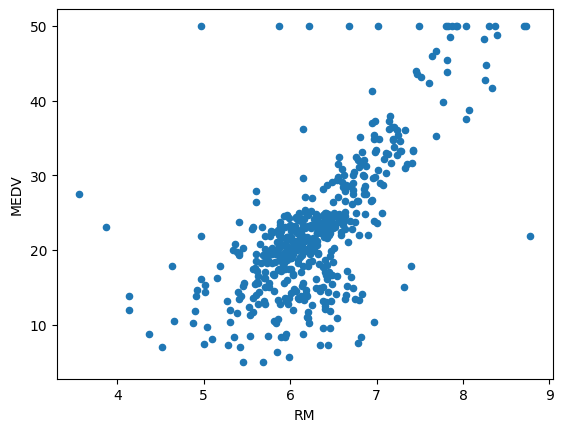

In [34]:
df.plot.scatter('RM','MEDV')
plt.show()

Para no tener que usar plt.show() podmeos usar la siguiente sentencia:

In [38]:
%matplotlib notebook

In [39]:
df.plot.scatter('RM','MEDV')

<IPython.core.display.Javascript object>

<Axes: xlabel='RM', ylabel='MEDV'>

Ahora usando la librería de pandas.

Vemos el parámetro alpha el cual permite hacer los puntos más suaves.

In [40]:
from pandas.plotting import scatter_matrix

In [51]:
scatter_matrix(df, alpha = 0.2, diagonal ='kde')
plt.show()

<IPython.core.display.Javascript object>

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
%matplotlib inline

plt.style.use('ggplot')

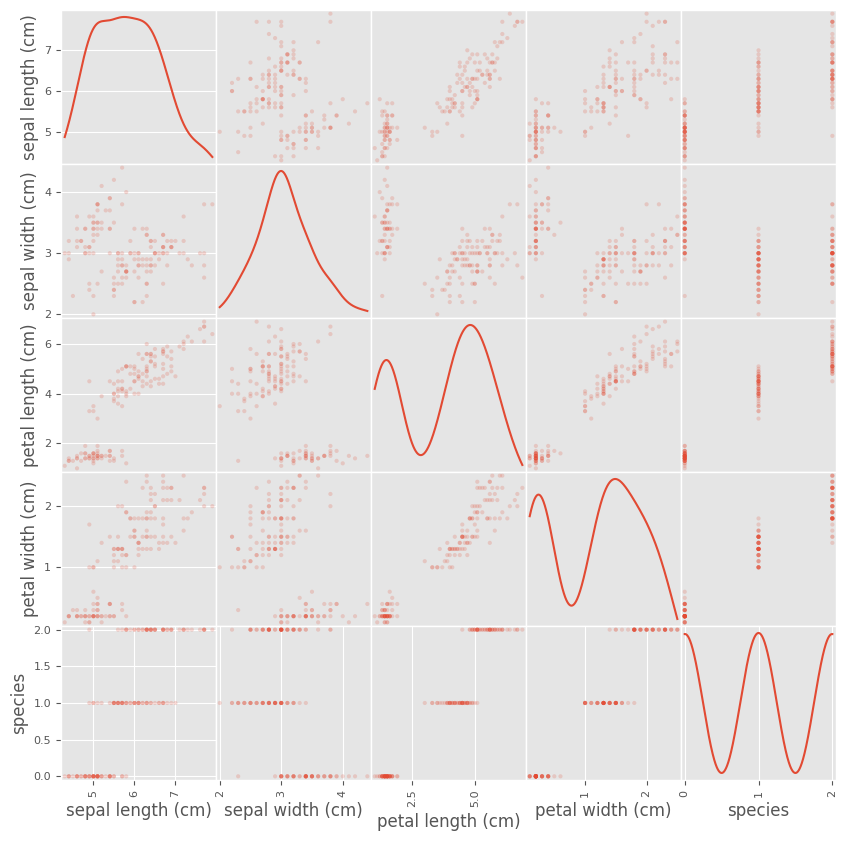

In [60]:
# Load some data
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris['data'], columns=iris['feature_names'])  # Remove 'diagonal' argument
iris_df['species'] = iris['target']

scatter_matrix(iris_df, alpha=0.2, figsize=(10, 10), diagonal='kde')  # Pass 'diagonal' to scatter_matrix
plt.show()

In [61]:
%matplotlib inline

<Axes: ylabel='Density'>

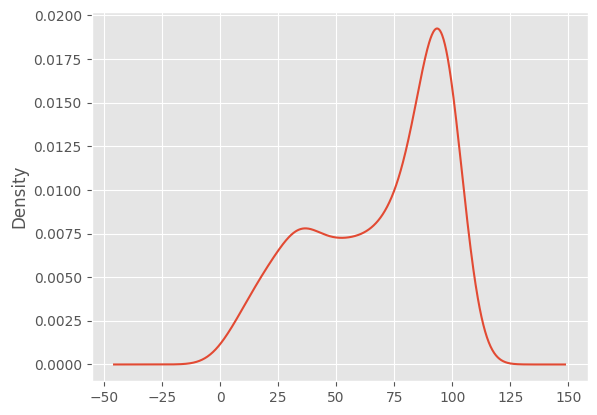

In [62]:
df.AGE.plot.kde() # kde es kernel density estimate

<Axes: ylabel='Frequency'>

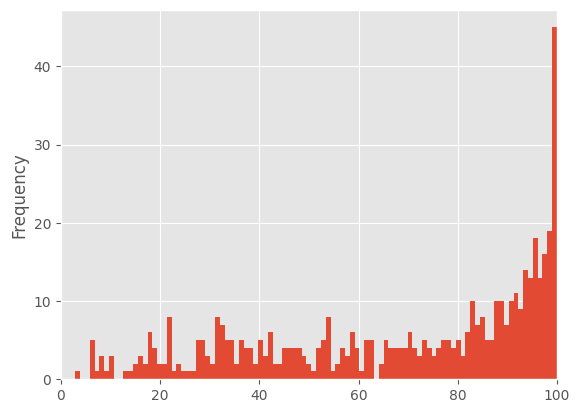

In [69]:
df.AGE.plot.hist(xlim=(0,100), bins = 100)

<Axes: >

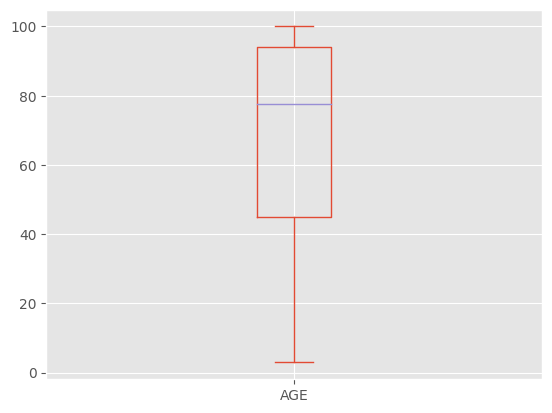

In [67]:
df.AGE.plot.box()

<Axes: >

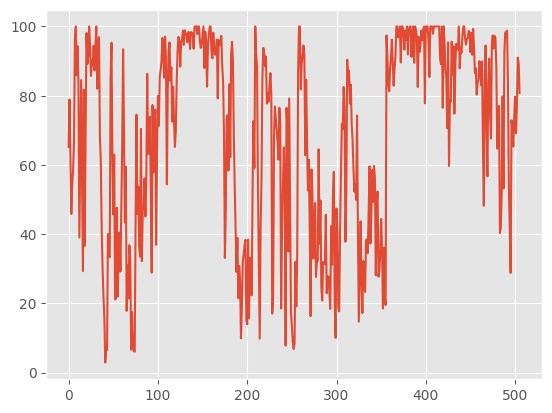

In [68]:
df.AGE.plot()

In [72]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [81]:
valor_por_flor = iris_df.groupby('species')['petal length (cm)'].mean()
valor_por_flor.head()

species
0    1.462
1    4.260
2    5.552
Name: petal length (cm), dtype: float64

<Axes: xlabel='species'>

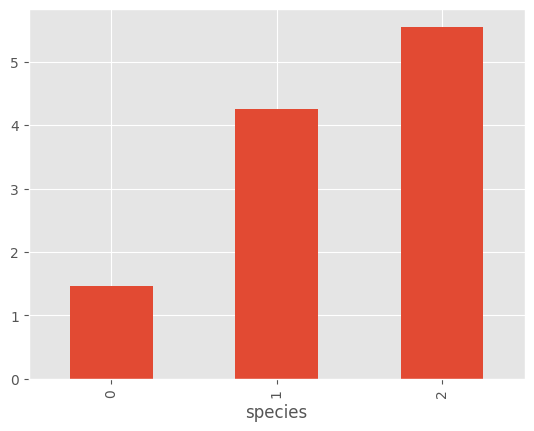

In [82]:
valor_por_flor.plot.bar()

<Axes: ylabel='species'>

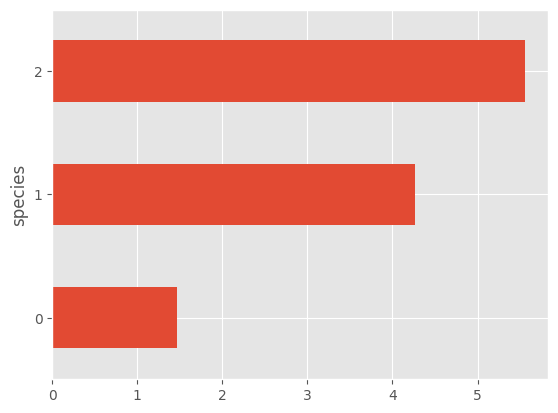

In [83]:
valor_por_flor.plot.barh()

<Axes: xlabel='species'>

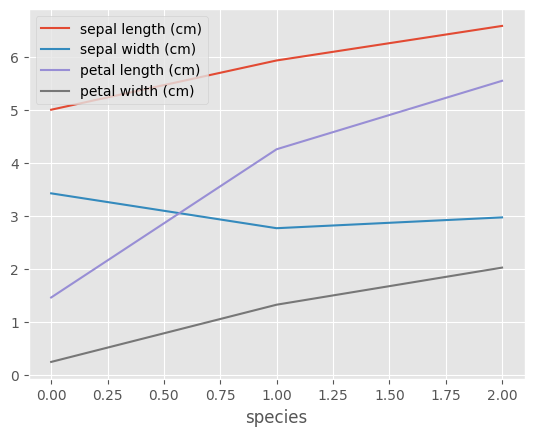

In [86]:
iris_df.groupby('species').mean().plot.line()

In [88]:
# con esto podemos contra facilmente cuántos valores de 0,1 y 2 tenemos de la columna
iris_df.species.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

<Axes: ylabel='count'>

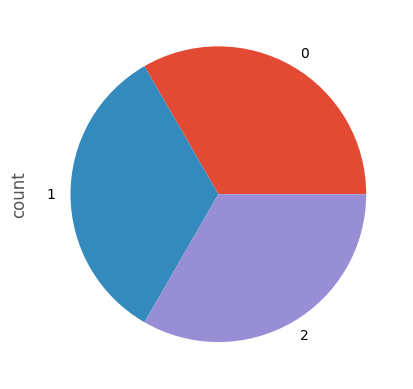

In [92]:
iris_df.species.value_counts().plot.pie()